In [2]:
import numpy as np
from scipy.signal import freqz
import matplotlib.pyplot as plt
from IPython.display import Audio      # βιβλιοθήκη για να "παίζουμε" ήχους (μεταξύ άλλων)

## Άσκηση - Ιδανικά φίλτρα επιλογής συχνότητας
Ένα *επιλεκτικό ως προς τη συχνότητα* φίλτρο (frequency-selective filter) είναι ένα ΓΧΑ σύστημα που αφήνει να περάσουν ορισμένες περιοχές συχνοτήτων του σήματος εισόδου (**ζώνη διέλευσης**) και αποκόπτει τις υπόλοιπες (**ζώνη αποκοπής**). 

Ανάλογα με το ποιες συχνότητες διατηρεί, διακρίνουμε τέσσερα βασικά είδη: 

το **χαμηλοπερατό**, το **υψιπερατό**, το **ζωνοπερατό** και το **ζωνοφρακτικό**.

Στην άσκηση αυτή θα κατασκευάσουμε ένα σήμα εισόδου που αποτελείται από **πολλές ημιτονοειδείς συνιστώσες** σε διαφορετικές συχνότητες, και θα δούμε πρακτικά την επίδραση καθενός από τα τέσσερα ιδανικά φίλτρα πάνω σε αυτό. Θα δουλέψουμε με δύο συμπληρωματικές οπτικές: 

- (α) την **αυστηρά ιδανική** απόκριση, την οποία υλοποιούμε στο πεδίο της συχνότητας (μάσκα DFT), και 

- (β) την **υλοποιήσιμη** προσέγγιση μέσω αποκομμένης κρουστικής απόκρισης (sinc), όπου θα εμφανιστεί το φαινόμενο Gibbs.

### Οι αποκρίσεις σε συχνότητα των τεσσάρων ιδανικών φίλτρων
Θυμηθείτε ότι η απόκριση σε συχνότητα ενός συστήματος διακριτού χρόνου, $H(e^{j\omega})$, είναι **περιοδική** με περίοδο $2\pi$, οπότε αρκεί να την ορίσουμε στο διάστημα $\omega \in [-\pi, \pi]$. Για ένα ιδανικό φίλτρο η απόκριση πλάτους είναι $1$ στη ζώνη διέλευσης και $0$ στη ζώνη αποκοπής (απότομη μετάβαση - «τοίχος»), ενώ η φάση θεωρείται μηδενική.

**Βαθυπερατό (lowpass)** με συχνότητα αποκοπής $\omega_c$:
$$H_{LP}(e^{j\omega}) = \begin{cases} 1, & |\omega| < \omega_c \\ 0, & \omega_c < |\omega| < \pi \end{cases}$$

**Υψιπερατό (highpass)** με συχνότητα αποκοπής $\omega_c$:
$$H_{HP}(e^{j\omega}) = 1 - H_{LP}(e^{j\omega}) = \begin{cases} 0, & |\omega| < \omega_c \\ 1, & \omega_c < |\omega| < \pi \end{cases}$$

**Ζωνοπερατό (bandpass)** με συχνότητες αποκοπής $\omega_{c1} < \omega_{c2}$:
$$H_{BP}(e^{j\omega}) = \begin{cases} 1, & \omega_{c1} < |\omega| < \omega_{c2} \\ 0, & \text{αλλού} \end{cases}$$

**Ζωνοφρακτικό (bandstop)** με συχνότητες αποκοπής $\omega_{c1} < \omega_{c2}$:
$$H_{BS}(e^{j\omega}) = 1 - H_{BP}(e^{j\omega}) = \begin{cases} 0, & \omega_{c1} < |\omega| < \omega_{c2} \\ 1, & \text{αλλού} \end{cases}$$

Παρατηρήστε ότι τα τέσσερα φίλτρα συνδέονται μεταξύ τους: το υψιπερατό είναι το «συμπλήρωμα» του βαθυπερατού, και το ζωνοφρακτικό το «συμπλήρωμα» του ζωνοπερατού. Επίσης, ένα ζωνοπερατό μπορεί να γραφεί ως διαφορά δύο βαθυπερατών: $$H_{BP} = H_{LP}(\omega_{c2}) - H_{LP}(\omega_{c1})$$

### i. Κατασκευή του σήματος εισόδου πολλαπλών συνιστωσών
(α') Θεωρήστε συχνότητα δειγματοληψίας $f_s = 8000$ Hz και κατασκευάστε ένα σήμα διακριτού χρόνου που αποτελείται από **τέσσερις** συνημιτονοειδείς συνιστώσες, καλά διαχωρισμένες στο φάσμα:

$$x[n] = \cos(\omega_1 n) + \cos(\omega_2 n) + \cos(\omega_3 n) + \cos(\omega_4 n), \qquad \omega_k = \frac{2\pi f_k}{f_s}$$

με $f_1 = 300$ Hz, $f_2 = 1200$ Hz, $f_3 = 2500$ Hz, $f_4 = 3500$ Hz. Πάρτε διάρκεια $1$ s ($N = f_s$ δείγματα) ώστε να μπορούμε να ακούσουμε το αποτέλεσμα. Σχεδιάστε ένα μικρό τμήμα του σήματος στο χρόνο και ακούστε το.

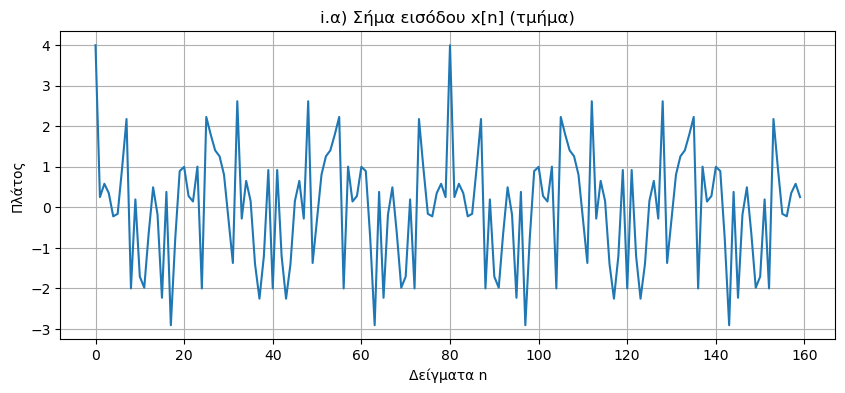

In [3]:
# i.α)
fs = 8000                     # συχνότητα δειγματοληψίας (Hz)
dur = 1.0                     # διάρκεια (s)
N = int(fs * dur)             # πλήθος δειγμάτων
n = np.arange(N)              # διάνυσμα διακριτού χρόνου 0..N-1

# Συχνότητες των συνιστωσών (Hz) και οι αντίστοιχες ψηφιακές συχνότητες ω = 2πf/fs
fk = np.array([300, 1200, 2500, 3500])
wk = 2 * np.pi * fk / fs

# Άθροισμα των τεσσάρων συνημιτόνων
x = np.zeros(N)
for w in wk:
    x = x + np.cos(w * n)

# Γραφική παράσταση ενός μικρού τμήματος στο χρόνο (τα πρώτα ~20 ms)
plt.figure(figsize=(10, 4))
plt.title('i.α) Σήμα εισόδου x[n] (τμήμα)')
plt.plot(n[:160], x[:160])
plt.grid(True)
plt.xlabel('Δείγματα n')
plt.ylabel('Πλάτος')
plt.show()

Audio(x, rate=fs)             # ακούμε το σήμα εισόδου :)

(β') Υπολογίστε το **φάσμα πλάτους** του $x[n]$ με χρήση του γρήγορου μετασχηματισμού Fourier ($\texttt{np.fft.fft}$) και επιβεβαιώστε ότι εμφανίζονται τέσσερις κορυφές, ακριβώς στις συχνότητες $\pm$ $f_1, f_2, f_3, f_4$.

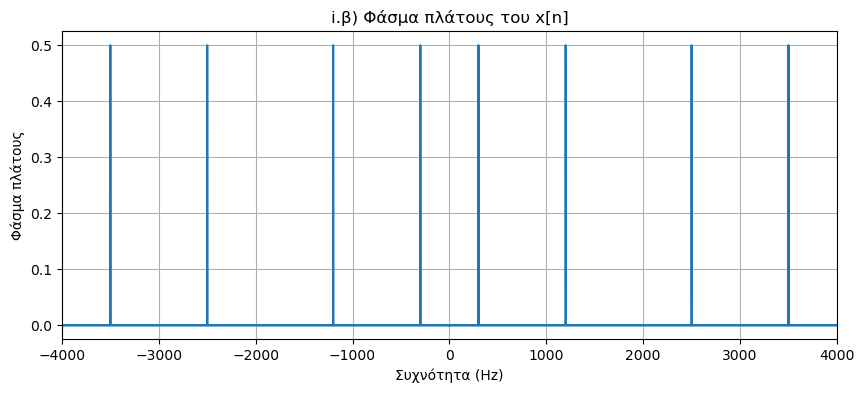

In [4]:
# i.β)
def fasma_platous(x, fs):
    """Επιστρέφει τον άξονα συχνοτήτων (Hz) και το φάσμα πλάτους του x."""
    N = len(x)
    X = np.fft.fft(x)                 # μετασχ. Fourier (μόνο θετικές συχνότητες)
    f = np.fft.fftfreq(N, d=1/fs)     # άξονας συχνοτήτων σε Hz
    mag = np.abs(X) / N            # κανονικοποίηση ώστε η κορυφή κάθε cos να ~1
    return f, mag

f, mag = fasma_platous(x, fs)

plt.figure(figsize=(10, 4))
plt.title('i.β) Φάσμα πλάτους του x[n]')
plt.plot(f, mag)
plt.grid(True)
plt.xlabel('Συχνότητα (Hz)')
plt.ylabel('Φάσμα πλάτους')
plt.xlim(-fs/2, fs/2)
plt.show()

Παρατηρούμε τέσσερις καθαρές κορυφές στα $300$, $1200$, $2500$ και $3500$ Hz, όσες και οι συνιστώσες. Ο οριζόντιος άξονας φτάνει έως $f_s/2 = 4000$ Hz (συχνότητα Nyquist). Στη συνέχεια, κάθε φίλτρο θα κρατά ή θα αποκόπτει επιλεκτικά κάποιες από αυτές τις κορυφές.

### ii. Αυστηρά ιδανικό φιλτράρισμα στο πεδίο της συχνότητας (μάσκα DFT)
Η κρουστική απόκριση ενός ιδανικού φίλτρου είναι **άπειρης διάρκειας και μη αιτιατή** (όπως θα δούμε στο μέρος iii), άρα το ιδανικό φίλτρο δεν είναι υλοποιήσιμο ως πραγματικό σύστημα. Μπορούμε όμως να δούμε **ακριβώς** την ιδανική συμπεριφορά αν εργαστούμε απευθείας στο πεδίο της συχνότητας: παίρνουμε τον DFT του σήματος, **μηδενίζουμε** τους συντελεστές που αντιστοιχούν στη ζώνη αποκοπής (πολλαπλασιασμός με μάσκα $0/1$ - το ανάλογο του $H(e^{j\omega})$), και επιστρέφουμε στο χρόνο με τον αντίστροφο DFT.

(α') Γράψτε μια συνάρτηση $\texttt{ideal\_filter}$ που δέχεται το σήμα, τη συχνότητα δειγματοληψίας, το είδος του φίλτρου και τις συχνότητες αποκοπής (σε Hz), και επιστρέφει το φιλτραρισμένο σήμα.

In [5]:
# ii.α)
def ideal_filter(x, fs, kind, fc):
    """
    Αυστηρά ιδανικό φιλτράρισμα με μάσκα στο πεδίο του DFT.
        x    : σήμα εισόδου
        fs   : συχνότητα δειγματοληψίας (Hz)
        kind : 'lp' (χαμηλοπερατό), 'hp' (υψιπερατό),
               'bp' (ζωνοπερατό),  'bs' (ζωνοφρακτικό)
        fc   : συχνότητα(-ες) αποκοπής σε Hz - αριθμός για lp/hp,
               ζεύγος [fc1, fc2] για bp/bs
    Επιστρέφει το φιλτραρισμένο σήμα (πραγματικό).
    """
    N = len(x)
    X = np.fft.fft(x)                       # DFT του σήματος
    freqs = np.fft.fftfreq(N, d=1/fs)       # συχνότητες κάθε συντελεστή (Hz)
    af = np.abs(freqs)                      # |f|: το φάσμα είναι συμμετρικό

    if kind == 'lp':
        H = (af <= fc)
    elif kind == 'hp':
        H = (af >= fc)
    elif kind == 'bp':
        H = (af >= fc[0]) & (af <= fc[1])
    elif kind == 'bs':
        H = ~((af >= fc[0]) & (af <= fc[1]))
    else:
        raise ValueError('Άγνωστο είδος φίλτρου: ' + str(kind))

    Y = X * H                               # εφαρμογή της ιδανικής μάσκας 0/1
    y = np.real(np.fft.ifft(Y))             # επιστροφή στο χρόνο
    return y

(β') **Βαθυπερατό.** Φιλτράρετε το $x[n]$ με ιδανικό βαθυπερατό φίλτρο συχνότητας αποκοπής $f_c = 1800$ Hz. Ποιες συνιστώσες αναμένετε να επιβιώσουν; Σχεδιάστε το φάσμα της εξόδου και ακούστε την.

<u>**Απάντηση**</u>

Αφού $f_c = 1800$ Hz, περνούν οι συνιστώσες κάτω από τα $1800$ Hz, δηλαδή τα $300$ και $1200$ Hz, ενώ αποκόπτονται τα $2500$ και $3500$ Hz.

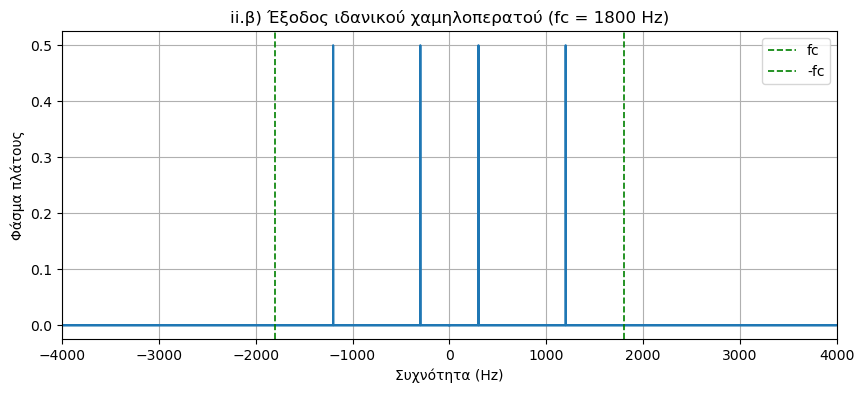

In [6]:
# ii.β) Χαμηλοπερατό
y_lp = ideal_filter(x, fs, 'lp', 1800)

f, mag = fasma_platous(y_lp, fs)
plt.figure(figsize=(10, 4))
plt.title('ii.β) Έξοδος ιδανικού χαμηλοπερατού (fc = 1800 Hz)')
plt.plot(f, mag)
plt.grid(True)
plt.xlabel('Συχνότητα (Hz)')
plt.ylabel('Φάσμα πλάτους')
plt.xlim(-fs/2, fs/2)
plt.axvline(1800, color='g', ls='--', lw=1.2, label='fc')
plt.axvline(-1800, color='g', ls='--', lw=1.2, label='-fc')
plt.legend()
plt.show()

Audio(y_lp, rate=fs)

(γ') **Υψιπερατό.** Επαναλάβετε με ιδανικό υψιπερατό φίλτρο, $f_c = 1800$ Hz.

<u>**Απάντηση**</u>

Τώρα περνούν οι συνιστώσες πάνω από τα $1800$ Hz, δηλαδή τα $2500$ και $3500$ Hz, ενώ αποκόπτονται τα $300$ και $1200$ Hz. Είναι το ακριβώς συμπληρωματικό αποτέλεσμα του χαμηλοπερατού.

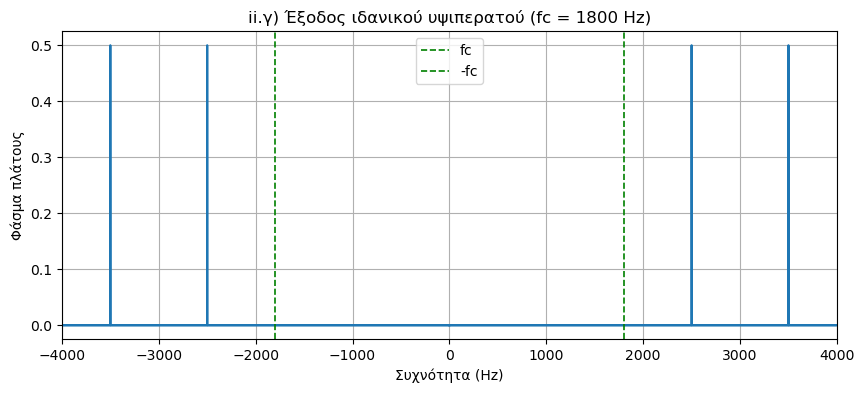

In [7]:
# ii.γ) Υψιπερατό
y_hp = ideal_filter(x, fs, 'hp', 1800)

f, mag = fasma_platous(y_hp, fs)
plt.figure(figsize=(10, 4))
plt.title('ii.γ) Έξοδος ιδανικού υψιπερατού (fc = 1800 Hz)')
plt.plot(f, mag)
plt.grid(True)
plt.xlabel('Συχνότητα (Hz)')
plt.ylabel('Φάσμα πλάτους')
plt.xlim(-fs/2, fs/2)
plt.axvline(1800, color='g', ls='--', lw=1.2, label='fc')
plt.axvline(-1800, color='g', ls='--', lw=1.2, label='-fc')
plt.legend()
plt.show()

Audio(y_hp, rate=fs)

(δ') **Ζωνοπερατό.** Φιλτράρετε το $x[n]$ με ιδανικό ζωνοπερατό φίλτρο με ζώνη διέλευσης $[f_{c1}, f_{c2}] = [800, 3000]$ Hz.

<u>**Απάντηση**</u>

Μέσα στη ζώνη $[800, 3000]$ Hz βρίσκονται τα $1200$ και $2500$ Hz, τα οποία και περνούν. Τα $300$ Hz (κάτω από τη ζώνη) και τα $3500$ Hz (πάνω από τη ζώνη) αποκόπτονται.

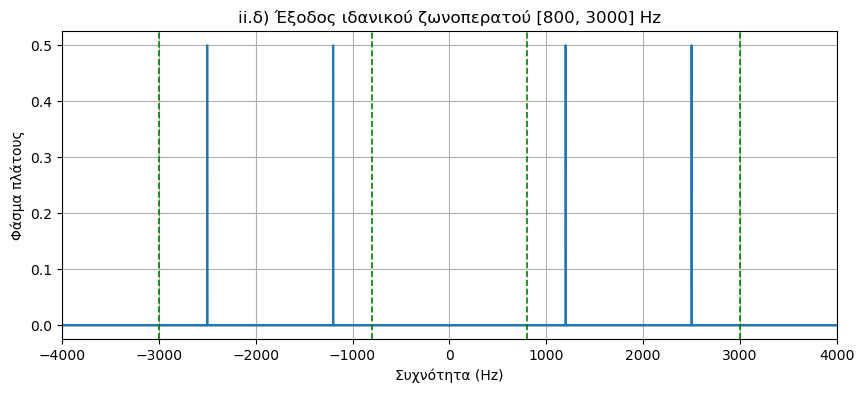

In [8]:
# ii.δ) Ζωνοπερατό
y_bp = ideal_filter(x, fs, 'bp', [800, 3000])

f, mag = fasma_platous(y_bp, fs)
plt.figure(figsize=(10, 4))
plt.title('ii.δ) Έξοδος ιδανικού ζωνοπερατού [800, 3000] Hz')
plt.plot(f, mag)
plt.grid(True)
plt.xlabel('Συχνότητα (Hz)')
plt.ylabel('Φάσμα πλάτους')
plt.xlim(-fs/2, fs/2)
plt.axvline(800, color='g', ls='--', lw=1.2)
plt.axvline(3000, color='g', ls='--', lw=1.2)
plt.axvline(-800, color='g', ls='--', lw=1.2)
plt.axvline(-3000, color='g', ls='--', lw=1.2)
plt.show()

Audio(y_bp, rate=fs)

(ε') **Ζωνοφρακτικό.** Τέλος, φιλτράρετε το $x[n]$ με ιδανικό ζωνοφρακτικό φίλτρο που αποκόπτει την ίδια ζώνη $[800, 3000]$ Hz.

<u>**Απάντηση**</u>

Το ζωνοφρακτικό είναι το συμπλήρωμα του ζωνοπερατού: αποκόπτει τα $1200$ και $2500$ Hz και αφήνει να περάσουν τα $300$ και $3500$ Hz.

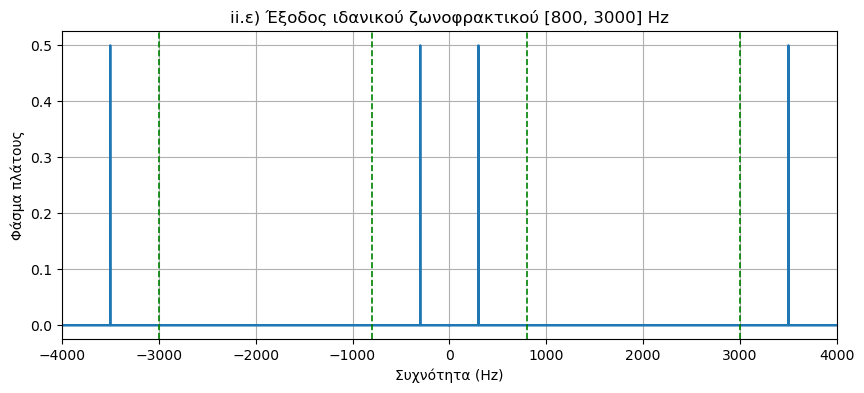

In [9]:
# ii.ε) Ζωνοφρακτικό
y_bs = ideal_filter(x, fs, 'bs', [800, 3000])

f, mag = fasma_platous(y_bs, fs)
plt.figure(figsize=(10, 4))
plt.title('ii.ε) Έξοδος ιδανικού ζωνοφρακτικού [800, 3000] Hz')
plt.plot(f, mag)
plt.grid(True)
plt.xlabel('Συχνότητα (Hz)')
plt.ylabel('Φάσμα πλάτους')
plt.xlim(-fs/2, fs/2)
plt.axvline(800, color='g', ls='--', lw=1.2)
plt.axvline(3000, color='g', ls='--', lw=1.2)
plt.axvline(-800, color='g', ls='--', lw=1.2)
plt.axvline(-3000, color='g', ls='--', lw=1.2)
plt.show()

Audio(y_bs, rate=fs)

### iii. Υλοποιήσιμη προσέγγιση: αποκομμένη κρουστική απόκριση (sinc)
Ας δούμε τώρα γιατί το ιδανικό φίλτρο δεν είναι υλοποιήσιμο. Η κρουστική απόκριση του ιδανικού χαμηλοπερατού φίλτρου προκύπτει ως ο αντίστροφος μετασχ. Fourier διακριτού χρόνου της συχνοτικής απόκρισης $H_{LP}(e^{j\omega})$:

$$h_{LP}[n] = \frac{1}{2\pi} \int_{-\omega_c}^{\omega_c} 1 \cdot e^{j\omega n}\, d\omega = \frac{\sin(\omega_c n)}{\pi n} = \frac{\omega_c}{\pi}\,\mathrm{sinc}\!\left(\frac{\omega_c n}{\pi}\right)$$

Πρόκειται για μια συνάρτηση $\mathrm{sinc}$ που εκτείνεται από το $-\infty$ έως το $+\infty$ και είναι **μη αιτιατή** (έχει τιμές για $n < 0$). Για να πάρουμε ένα υλοποιήσιμο φίλτρο την **αποκόπτουμε** σε ένα πεπερασμένο παράθυρο $n \in [-M, M]$. Αυτή η αποκοπή είναι που εισάγει σφάλματα σε σχέση με το ιδανικό.

(α') Κατασκευάστε την αποκομμένη κρουστική απόκριση ενός βαθυπερατού με $f_c = 1800$ Hz (δηλ. $\omega_c = 2\pi \cdot 1800 / f_s = 0.45\pi$) και $M = 200$, και σχεδιάστε την.

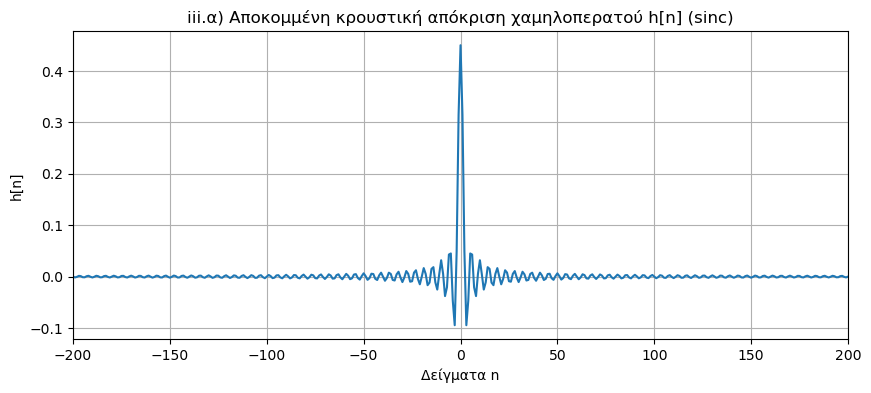

In [10]:
# iii.α) Αποκομμένη ιδανική κρουστική απόκριση (sinc)
fc = 1800
wc = 2 * np.pi * fc / fs        # ψηφιακή συχνότητα αποκοπής (rad/δείγμα)
M = 200                         # μισό μήκος του παραθύρου -> μήκος 2M+1
nh = np.arange(-M, M + 1)       # συμμετρικό διάνυσμα δειγμάτων

# h[n] = (wc/π) sinc(wc n / π)
h_lp = (wc / np.pi) * np.sinc(wc * nh / np.pi)

plt.figure(figsize=(10, 4))
plt.title('iii.α) Αποκομμένη κρουστική απόκριση χαμηλοπερατού h[n] (sinc)')
plt.plot(nh, h_lp)
plt.grid(True)
plt.xlabel('Δείγματα n')
plt.ylabel('h[n]')
plt.xlim(-M, M)
plt.show()

(β') Υπολογίστε και σχεδιάστε την **απόκριση πλάτους** του αποκομμένου φίλτρου με χρήση της $\texttt{sig.freqz}$. Συγκρίνετέ την με την ιδανική (τον «τοίχο»). Τι παρατηρείτε;

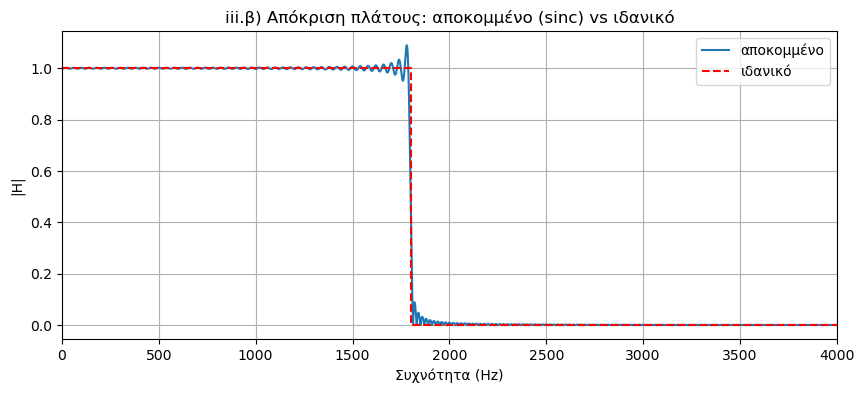

In [13]:
# iii.β) Απόκριση πλάτους του αποκομμένου φίλτρου
W, H = freqz(h_lp, 1, worN=4096)
f_axis = W * fs / (2 * np.pi)          # μετατροπή ω -> Hz

plt.figure(figsize=(10, 4))
plt.title('iii.β) Απόκριση πλάτους: αποκομμένο (sinc) vs ιδανικό')
plt.plot(f_axis, np.abs(H), label='αποκομμένο')
plt.plot([0, fc, fc, fs/2], [1, 1, 0, 0], 'r--', label='ιδανικό')
plt.grid(True)
plt.xlabel('Συχνότητα (Hz)')
plt.ylabel('|H|')
plt.xlim(0, fs/2)
plt.legend()
plt.show()

Βλέπουμε ότι το υλοποιήσιμο φίλτρο **δεν** έχει απότομη μετάβαση: υπάρχει μια ζώνη μετάβασης πεπερασμένου πλάτους γύρω από τα $1800$ Hz, και - το πιο χαρακτηριστικό - εμφανίζονται **κυματώσεις (ripples)** τόσο στη ζώνη διέλευσης όσο και στη ζώνη αποκοπής. Πρόκειται για το **φαινόμενο Gibbs**, άμεση συνέπεια της απότομης αποκοπής της $\mathrm{sinc}()$ στο χρόνο (ισοδύναμα, της συνέλιξης του ιδανικού «τοίχου» με το φάσμα του ορθογώνιου παραθύρου). 

Αυξάνοντας το $M$ η μετάβαση γίνεται πιο απότομη, όμως το **ύψος** της κυμάτωσης κοντά στην ασυνέχεια δεν μηδενίζεται ποτέ (μένει ~9%)· χρειάζεται κατάλληλη παραθύρωση (π.χ. Hamming) για να το μειώσουμε.

(γ') Φιλτράρετε το σήμα $x[n]$ με το αποκομμένο βαθυπερατό (με $\texttt{np.convolve}$) και συγκρίνετε το φάσμα της εξόδου με εκείνο του αυστηρά ιδανικού βαθυπερατού του μέρους ii.β.

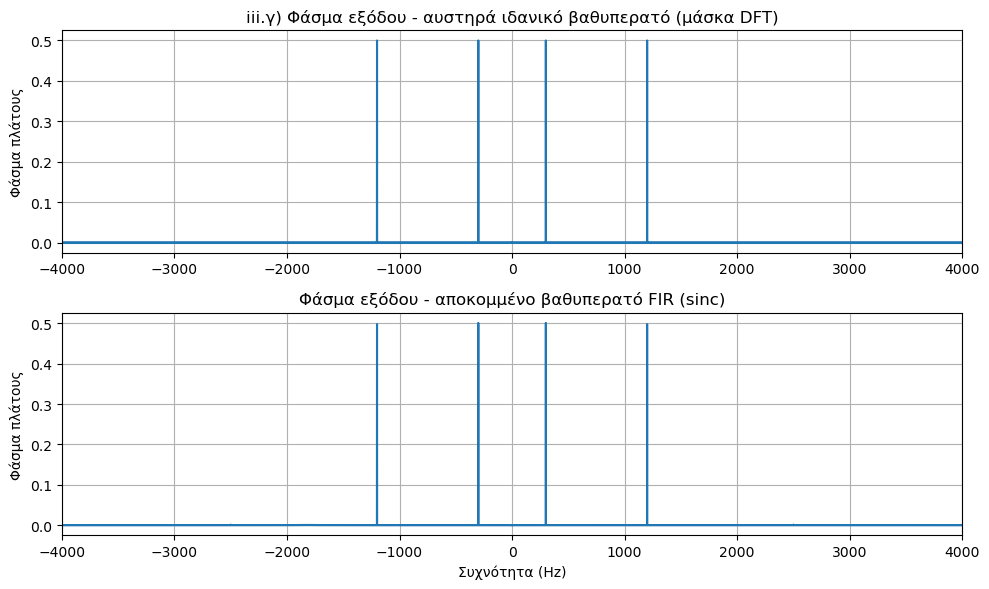

In [16]:
# iii.γ) Φιλτράρισμα με το αποκομμένο FIR
y_fir = np.convolve(x, h_lp, mode='same')

f1, mag1 = fasma_platous(y_lp,  fs)     # αυστηρά ιδανικό (ii.β)
f2, mag2 = fasma_platous(y_fir, fs)     # αποκομμένο FIR

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.title('iii.γ) Φάσμα εξόδου - αυστηρά ιδανικό βαθυπερατό (μάσκα DFT)')
plt.plot(f1, mag1)
plt.grid(True)
plt.ylabel('Φάσμα πλάτους')
plt.xlim(-fs/2, fs/2)

plt.subplot(2, 1, 2)
plt.title('Φάσμα εξόδου - αποκομμένο βαθυπερατό FIR (sinc)')
plt.plot(f2, mag2)
plt.grid(True)
plt.xlabel('Συχνότητα (Hz)')
plt.ylabel('Φάσμα πλάτους')
plt.xlim(-fs/2, fs/2)
plt.tight_layout()
plt.show()

Audio(y_fir, rate=fs)

Και τα δύο κρατούν τις συνιστώσες $300$ και $1200$ Hz. 

Στο ιδανικό φίλτρο οι συνιστώσες της ζώνης αποκοπής μηδενίζονται **ακριβώς**. Στο αποκομμένο φίλτρο παραμένουν πολύ μικρά ίχνη τους (λόγω του ripple στη ζώνη αποκοπής), ενώ τα πλάτη στη ζώνη διέλευσης δεν είναι απολύτως ίσα με $1$. 

Επιπλέον, το αποκομμένο φίλτρο εισάγει **καθυστέρηση** $M$ δειγμάτων (γραμμική φάση) - εδώ την αντισταθμίσαμε προσεγγιστικά με $\texttt{mode='same'}$.

### iv. Σχολιασμός: ιδανικό vs υλοποιήσιμο
Συνοψίζοντας:
- Το **ιδανικό** φίλτρο ($|H(e^{j\omega})| = 1$ ή $0$, μηδενική ζώνη μετάβασης) υπάρχει μόνο ως μαθηματική ιδεατή περιγραφή. Η κρουστική του απόκριση είναι άπειρης διάρκειας και μη αιτιατή, άρα δεν υλοποιείται σε πραγματικό χρόνο. Το προσομοιώσαμε «ακριβώς» μόνο επειδή δουλέψαμε εκ των υστέρων (offline) στο πεδίο του DFT ολόκληρου του σήματος.

- Κάθε **υλοποιήσιμο** φίλτρο έχει πεπερασμένη ζώνη μετάβασης, κάποια κυμάτωση, και μη μηδενική καθυστέρηση. Η αποκοπή της $\mathrm{sinc}()$ εισάγει το φαινόμενο Gibbs· στην πράξη χρησιμοποιούμε τεχνικές σχεδίασης (παραθύρωση, βέλτιστα FIR κατά Parks–McClellan, ή αναδρομικά IIR φίλτρα τύπου Butterworth/Chebyshev) που ανταλλάσσουν οξύτητα μετάβασης, κυμάτωση και τάξη του φίλτρου.

Το βασικό συμπέρασμα είναι ότι τα τέσσερα ιδανικά φίλτρα ορίζουν τον **στόχο** (ποιες συχνότητες θέλουμε να κρατήσουμε), ενώ η πραγματική σχεδίαση φίλτρου είναι το πρόβλημα της **προσέγγισης** αυτού του στόχου με πεπερασμένους πόρους.

---

---